# LeetCode #124: Binary Tree Maximum Path Sum

https://leetcode.com/problems/binary-tree-maximum-path-sum/

## Comparison of Approaches

| Approach | Time | Space | Notes |
|----------|------|-------|-------|
| Brute force (enumerate all paths) | O(n²) | O(n) | TLE on large trees |
| **DFS Post-Order + Global Max** | **O(n)** | **O(h)** | **Optimal — single traversal** |

## Understanding the Method

At each node during DFS:
- Get max gain from left subtree: `left = max(0, dfs(left))` (clamp negatives)
- Get max gain from right subtree: `right = max(0, dfs(right))`
- Update global answer: `ans = max(ans, node.val + left + right)` (path through this node)
- Return to parent: `node.val + max(left, right)` (can only choose one branch going up)

## Constraints

- Number of nodes: `[1, 3 * 10^4]`
- `-1000 <= Node.val <= 1000`

## Solutions

### C#

In [ ]:
public class Solution {
    int ans = int.MinValue;
    public int MaxPathSum(TreeNode root) {
        Dfs(root);
        return ans;
    }
    int Dfs(TreeNode node) {
        if (node == null) return 0;
        int left  = Math.Max(0, Dfs(node.left));
        int right = Math.Max(0, Dfs(node.right));
        ans = Math.Max(ans, node.val + left + right);
        return node.val + Math.Max(left, right);
    }
}

### Python

In [ ]:
class Solution:
    def maxPathSum(self, root) -> int:
        self.ans = float('-inf')
        def dfs(node):
            if not node:
                return 0
            left  = max(0, dfs(node.left))
            right = max(0, dfs(node.right))
            self.ans = max(self.ans, node.val + left + right)
            return node.val + max(left, right)
        dfs(root)
        return self.ans

### Go

In [ ]:
import "math"

func maxPathSum(root *TreeNode) int {
    ans := math.MinInt32
    var dfs func(*TreeNode) int
    dfs = func(node *TreeNode) int {
        if node == nil {
            return 0
        }
        left  := max(0, dfs(node.Left))
        right := max(0, dfs(node.Right))
        if node.Val+left+right > ans {
            ans = node.Val + left + right
        }
        return node.Val + max(left, right)
    }
    dfs(root)
    return ans
}

func max(a, b int) int {
    if a > b { return a }
    return b
}

### Rust

In [ ]:
use std::rc::Rc;
use std::cell::RefCell;

impl Solution {
    pub fn max_path_sum(root: Option<Rc<RefCell<TreeNode>>>) -> i32 {
        let mut ans = i32::MIN;
        Self::dfs(&root, &mut ans);
        ans
    }
    fn dfs(node: &Option<Rc<RefCell<TreeNode>>>, ans: &mut i32) -> i32 {
        if let Some(n) = node {
            let n = n.borrow();
            let left  = Self::dfs(&n.left, ans).max(0);
            let right = Self::dfs(&n.right, ans).max(0);
            *ans = (*ans).max(n.val + left + right);
            n.val + left.max(right)
        } else {
            0
        }
    }
}

## Example Scenarios

### 1. Common Case
**Input:** `root = [-10, 9, 20, null, null, 15, 7]`  
At node 20: left gain $= 15$, right gain $= 7$, through-path $= 15 + 20 + 7 = 42$. At root $-10$: through-path $= 9 + (-10) + 35 = 34$. Global max $= 42$.  
WHY tricky: Path through node 20 $(42)$ beats path through root $(34)$. Global max tracks best across all nodes. LaTeX: $\text{ans} = \max(\text{ans},\, v + L + R)$.

### 2. Slightly Complex -- Root Connects Both Sides
**Input:** `root = [1, 2, 3]`  
At root: left $= 2$, right $= 3$, through-path $= 2 + 1 + 3 = 6$. Return to parent $= 1 + \max(2, 3) = 4$. Full path uses both branches.  
WHY tricky: Can't return both branches to parent (path would fork). Return $\max(L, R) + v$, but record both-sides in global max. LaTeX: $\text{return} = v + \max(L, R)$.

### 3. Edge Case: Time Factor
**Input:** Complete binary tree with $30{,}000$ nodes, values in $[-1000, 1000]$  
DFS visits every node exactly once: $O(n) = 30{,}000$ operations. Height $= \log_2(30000) \approx 15$ levels -- no stack overflow.  
WHY tricky: $O(n)$ is optimal since every node must be examined. Post-order avoids redundant work. LaTeX: $T(n) = O(n)$, $\text{depth} = O(\log n)$.

### 4. Edge Case: Space Factor
**Input:** $30{,}000$ nodes in a single chain (all left children)  
Recursion depth $= n = 30{,}000$. Stack space $= O(n)$. Worst case for space; may cause stack overflow in some languages.  
WHY tricky: Skewed tree turns $O(\log n)$ stack into $O(n)$. In interviews, mention iterative post-order as alternative. LaTeX: $h = n \Rightarrow O(n)$ stack.

### 5. Almost-Impossible but Plausible
**Input:** $30{,}000$ nodes, all values $= -1000$  
Every subtree gain clamped to $\max(0, \text{negative}) = 0$. Through-path at each node $= \text{node.val}$. Global max $= -1000$ (single node). Must not return $0$.  
WHY tricky: Clamping is for child contributions, not the node itself. Path must contain $\ge 1$ node. LaTeX: $\text{ans} = \max_{v \in V}(v.\text{val}) = -1000$.

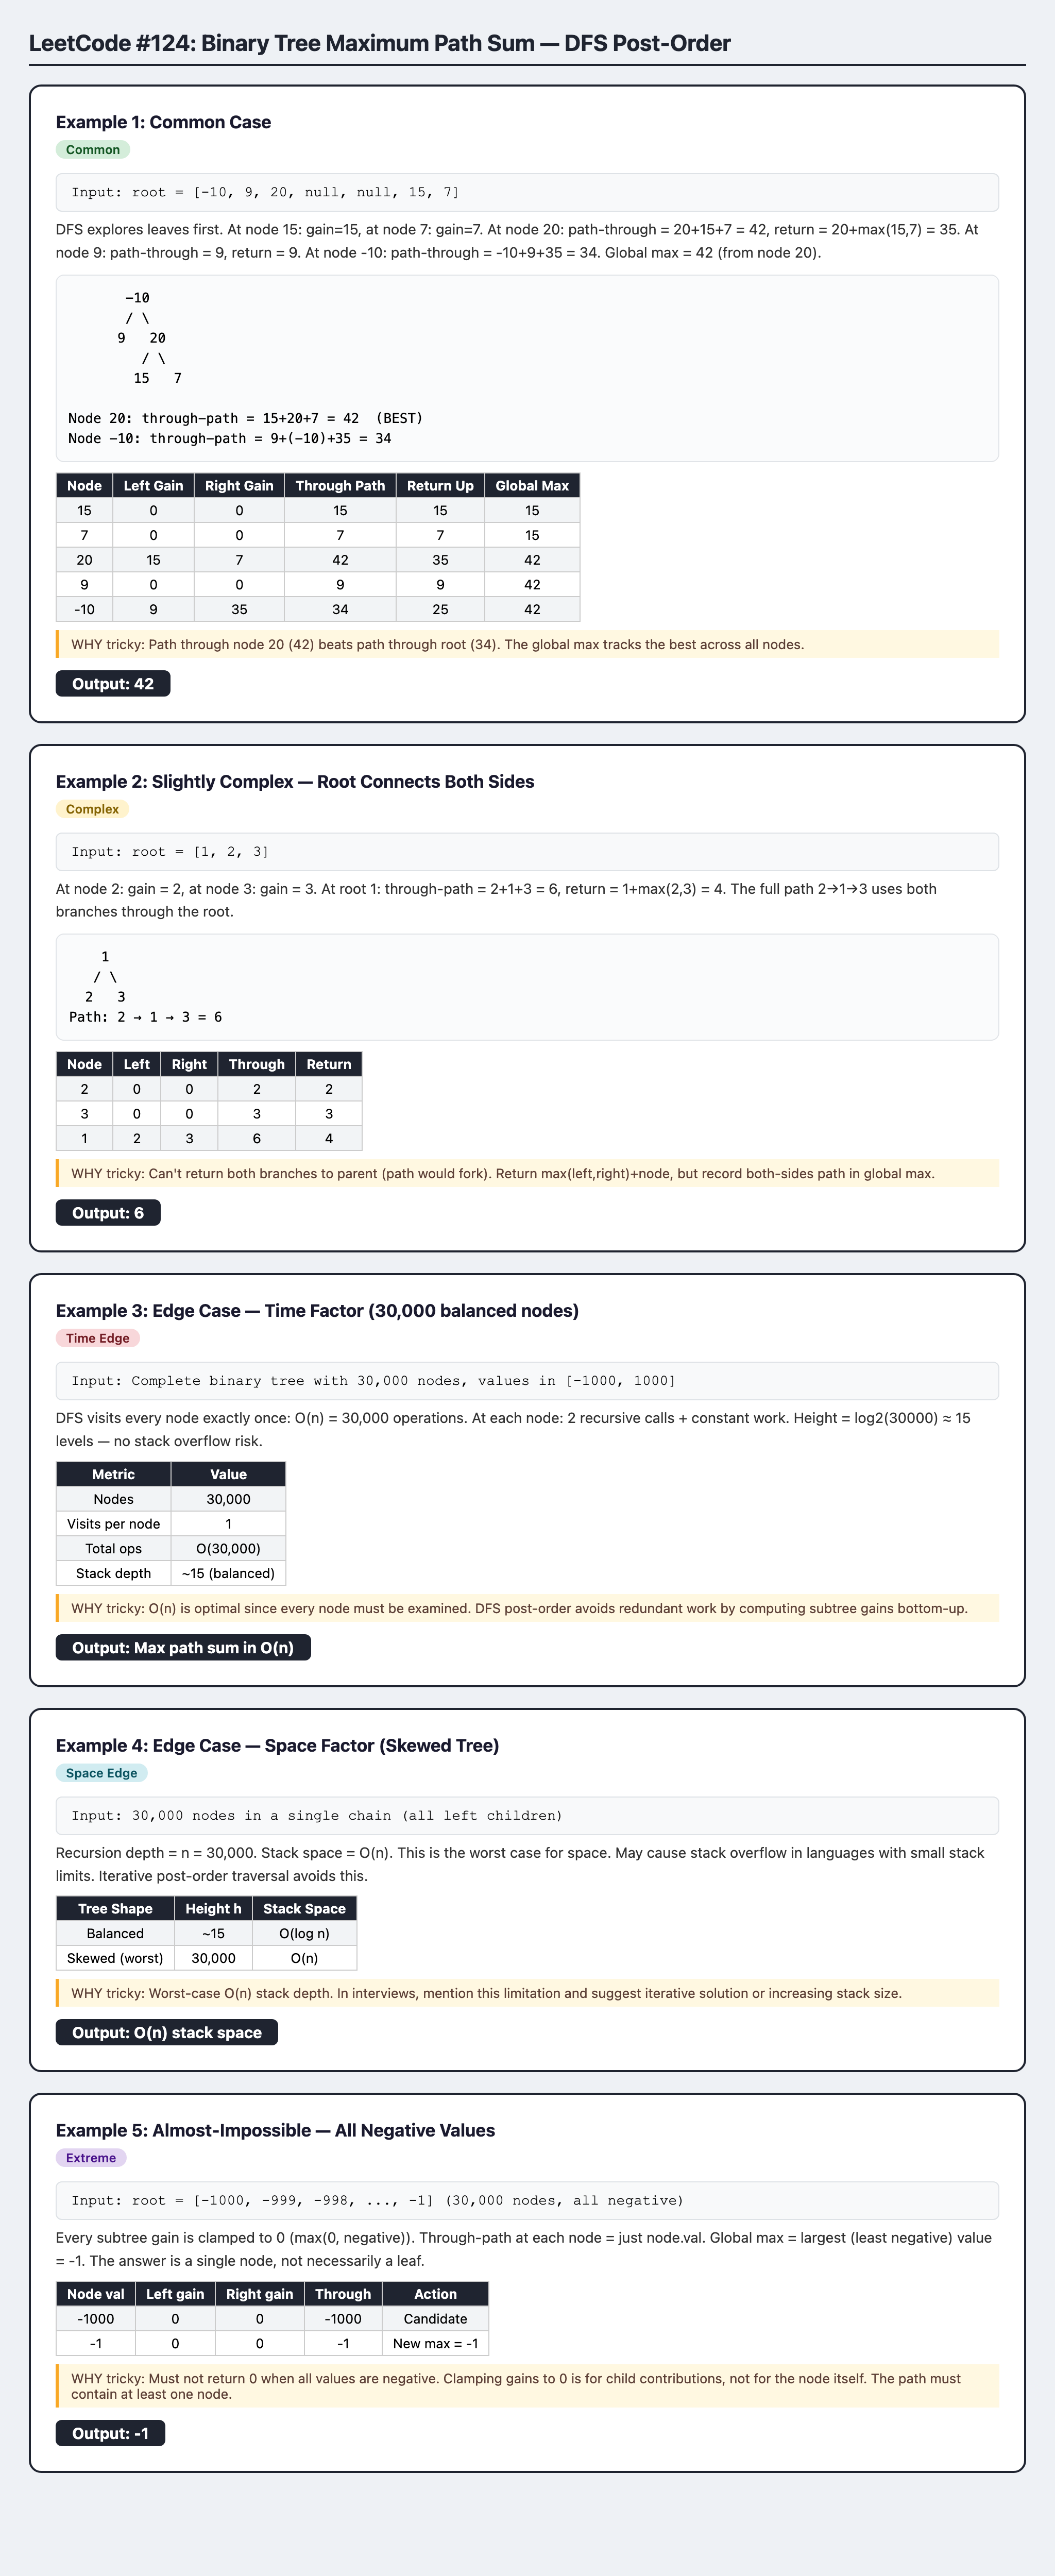